<a href="https://www.kaggle.com/code/samratrm/s6e7-eda-student-health-risk?scriptVersionId=339755858" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Student Heath Risk EDA

### **Problem Statement & Competition Objective**

* **Context:** Modern college students experience complex interactions between daily habits, physiological metrics, and stress factors that impact their overall health.
* **Objective:** Build a multi-class classification model to predict a student's **`health_condition`** into one of three risk tiers:
    * **`fit`**: Healthy & balanced condition
    * **`at-risk`**: Moderate health concerns (Majority class)
    * **`unhealthy`**: High health risk


* **Evaluation Metric:** **Balanced Accuracy** — treats all three classes equally, penalizing models that favor the majority class (`at-risk`).

### Imports

In [1]:
!pip install umap-learn

In [2]:
import numpy as np
import pandas as pd
import os
import kagglehub
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


In [4]:
df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## Data Understanding

#### **Dataset Overview & Structure**

* **Dataset Origin:** Synthetically generated dataset modeled after large-scale college student health studies, blending survey data, wearable device logs, and health records.
* **Feature Breakdown:**
    * **Numerical (Physiological & Wearable Logs):** `sleep_duration`, `heart_rate`, `bmi`, `calorie_expenditure`, `step_count`, `exercise_duration`, and `water_intake`.
    * **Categorical (Behavioral & Psychological):** `diet_type`, `stress_level`, `sleep_quality`, `physical_activity_level`, `smoking_alcohol`, and `gender`.


* **Synthetic Data Characteristics:** Modeled on real-world distributions, but contains synthetic artifacts (such as boundary spikes, zero-inflation mass, and multimodal distribution patterns) that offer distinct feature engineering opportunities.

In [5]:
df.shape

(690088, 15)

In [6]:
df.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

In [7]:
quantative = df.select_dtypes(['number']).columns.to_list()
qualitative = df.select_dtypes(['object']).columns.to_list()
qualitative.remove('health_condition')
quantative.remove("id")

print(f"Quantative: {quantative},\n Qualitative: {qualitative}")

Quantative: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake'],
 Qualitative: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [8]:
df.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [9]:
for col in qualitative:
    print(df[col].value_counts(),'\n')

diet_type
veg         231432
balanced    226888
non-veg     224867
Name: count, dtype: int64 

stress_level
medium    261819
high      177750
low       167708
Name: count, dtype: int64 

sleep_quality
average    213948
poor       212166
good       205643
Name: count, dtype: int64 

physical_activity_level
moderate     221041
sedentary    219784
active       212642
Name: count, dtype: int64 

smoking_alcohol
yes           223730
no            219791
occasional    217985
Name: count, dtype: int64 

gender
male      237756
female    224016
other     206943
Name: count, dtype: int64 



**Categorical Feature Strategy:**
* **Low Cardinality:** Every qualitative feature (`diet_type`, `stress_level`, `sleep_quality`, `physical_activity_level`, `smoking_alcohol`, `gender`) contains exactly **3 unique categories**.
* **Encoding Plan:** Standard One-Hot Encoding (OHE) is lightweight and well-suited. However, ordered features (e.g., `stress_level`, `sleep_quality`) can also be tested with **Ordinal Encoding** to preserve feature hierarchy.

### Datatype Converstion

In [10]:
df = df.set_index("id")
df[qualitative] = df[qualitative].astype("category")
df['health_condition'] = df['health_condition'].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 690088 entries, 0 to 690087
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   health_condition         690088 non-null  category
 1   sleep_duration           614089 non-null  float64 
 2   heart_rate               682255 non-null  float64 
 3   bmi                      676190 non-null  float64 
 4   calorie_expenditure      637235 non-null  float64 
 5   step_count               676172 non-null  float64 
 6   exercise_duration        683187 non-null  float64 
 7   water_intake             646611 non-null  float64 
 8   diet_type                683187 non-null  category
 9   stress_level             607277 non-null  category
 10  sleep_quality            631757 non-null  category
 11  physical_activity_level  653467 non-null  category
 12  smoking_alcohol          661506 non-null  category
 13  gender                   668715 non-null  categor

# Exploratory Data Analysis 

## Missing Values

In [11]:
pct_rows_with_na = df.isna().any(axis=1).mean() * 100
print(f"Percentage of Rows with atleast one missing value : {pct_rows_with_na}")

Percentage of Rows with atleast one missing value : 49.33646143680227


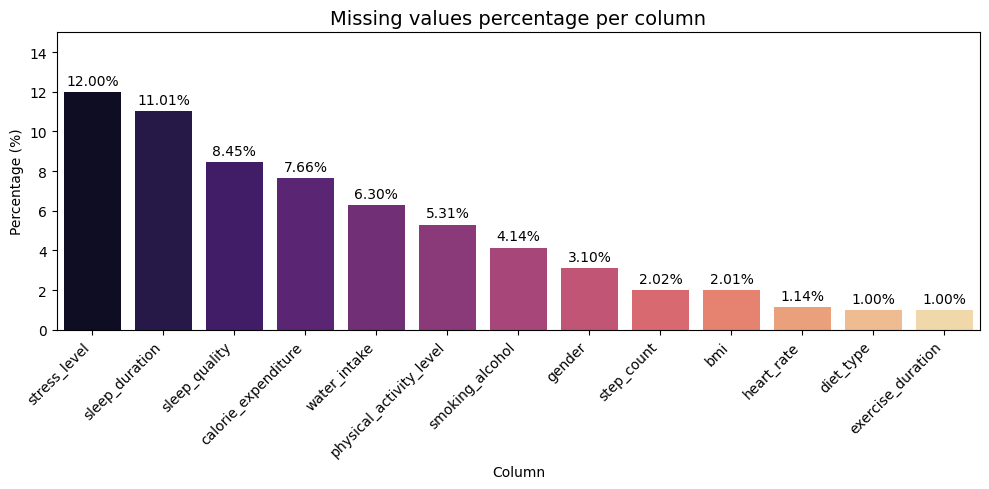

In [12]:
missing_col = df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)
missing_df = (( missing_col / df.shape[0]) * 100).reset_index()
missing_df.columns = ['Column', 'Missing_Percentage']

plt.figure(figsize=(10,5))
ax = sns.barplot(data=missing_df, x="Column", y='Missing_Percentage', palette='magma', hue='Column')

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.title("Missing values percentage per column", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Percentage (%)")
plt.ylim(0, missing_df['Missing_Percentage'].max() + 3)
plt.tight_layout()

plt.show()

#### Testing Hypothesis

**Hypothesis (H1):** Missing values in `exercise_duration` might represent zero minutes of exercise. 

In [13]:
df[['health_condition']][df['exercise_duration'].isna()].value_counts(normalize=True)

health_condition
at-risk             0.850891
unhealthy           0.088683
fit                 0.060426
Name: proportion, dtype: float64

In [14]:
df[['health_condition']][df['exercise_duration'].notna()].value_counts(normalize=True)

health_condition
at-risk             0.858753
unhealthy           0.083596
fit                 0.057650
Name: proportion, dtype: float64

### Missing Values Co-ocurance:

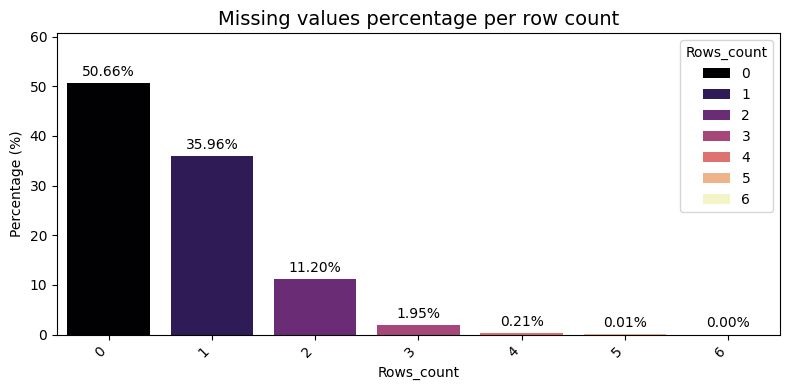

In [15]:
missing_values_rows = df.isna().sum(axis=1).value_counts()
missing_row_df = ((missing_values_rows / df.shape[0]) * 100).reset_index()

missing_row_df = (( missing_values_rows / df.shape[0]) * 100).reset_index()
missing_row_df.columns = ['Rows_count', 'Missing_Percentage']

plt.figure(figsize=(8,4))
ax = sns.barplot(data=missing_row_df, x="Rows_count", y='Missing_Percentage', palette='magma', hue='Rows_count')

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.title("Missing values percentage per row count", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Percentage (%)")
plt.ylim(0, missing_row_df['Missing_Percentage'].max() + 10)
plt.tight_layout()

plt.show()

### Duplicate Rows 

In [16]:
# Check duplicates across all columns except 'id'
df.duplicated(subset=df.columns.difference(['id'])).sum()

np.int64(0)

### Missing Value Distribution Across Target Classes

#### Objective & Motivation

Because the competition evaluation metric is `balanced_accuracy`, each target class (at-risk, unhealthy, fit) contributes equally to the final score regardless of class size.

If missing feature values were concentrated heavily in minority classes (fit or unhealthy), improper imputation could disproportionately harm prediction quality for those classes and significantly drag down the overall balanced accuracy score.

In [17]:
records = []

for col in missing_df["Column"]:
    for health_class in df["health_condition"].dropna().unique():
        class_total = (df["health_condition"] == health_class).sum() 
        class_missing = (
            df[df[col].isna()]['health_condition']
            .value_counts()
            .get(health_class,0)
        )

        records.append(
            {
                "Column": col,
                "health_condition": health_class,
                "Class_missing_pct": (class_missing/class_total) * 100,
            }
        )
missing_class_norm = pd.DataFrame(records)
missing_class_norm.groupby('health_condition').agg({"Class_missing_pct":'sum'})

,Class_missing_pct
health_condition,
at-risk,65.215733
fit,65.733739
unhealthy,63.905828


#### **Key Findings**

* **Class-Normalized Analysis:** To account for the severe class imbalance (~85% `at-risk` vs. ~6% `fit`), we calculated the **within-class missing rate** for each feature:

$$\text{Class Missing Rate (\%)} = \frac{\text{Missing rows in Column } X \text{ with Class } C}{\text{Total rows in Class } C} \times 100$$


* **Uniform Missingness Pattern:** Across all features, the average missing features rate remains nearly identical across target classes:
* **`at-risk`**: ~65.2%
* **`fit`**: ~65.7%
* **`unhealthy`**: ~63.9%


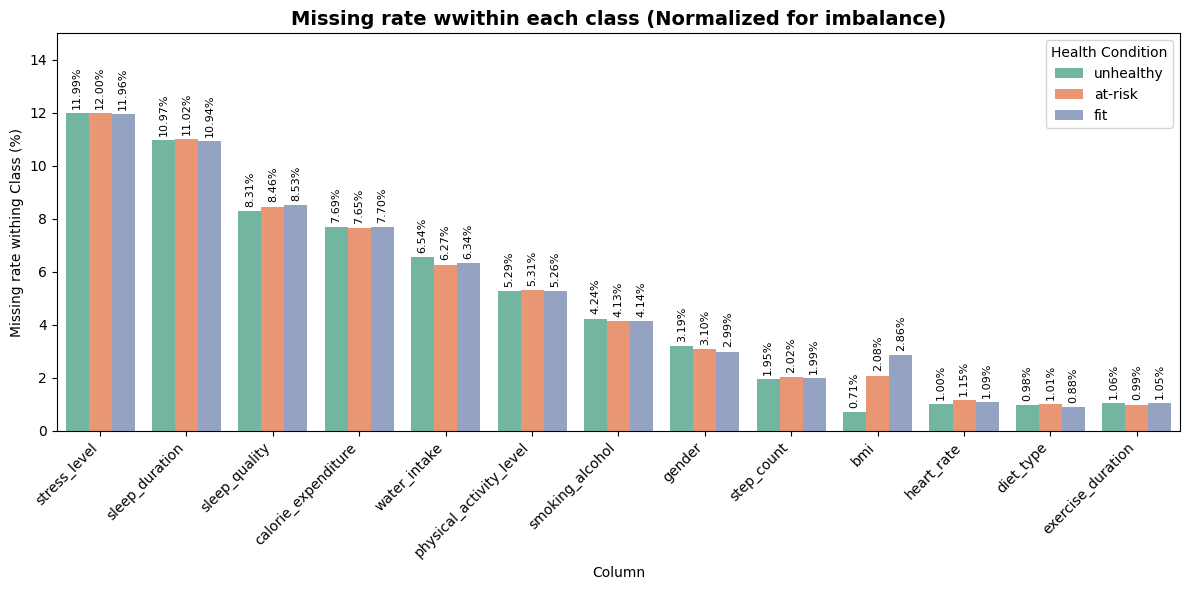

In [18]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=missing_class_norm,
    x='Column',
    y='Class_missing_pct',
    hue='health_condition',
    palette='Set2',
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=8, rotation=90)

plt.title("Missing rate wwithin each class (Normalized for imbalance)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Missing rate withing Class (%)")
plt.ylim(0, missing_class_norm['Class_missing_pct'].max() + 3)
plt.legend(title="Health Condition")
plt.tight_layout()
plt.show()

In [19]:
test['bmi'].isna().sum() / test.shape[0]

np.float64(0.020138426321964612)

**Key Insight (`bmi` Anomaly):**
 * **Non-Random Pattern:** Unlike other features, `bmi` missingness varies heavily by class missing values are ~4x more likely to be fit than unhealthy.

* **Significant Signal:** Affecting ~14k rows in `train` and ~2% of `test`, this gap is too large to be random noise.


* **Action:** Create an indicator feature (`bmi_is_missing`) prior to imputation to preserve this predictive signal for the model.


#### **Summary of Missing Data Findings & Strategy**

* **Hypothesis Disproved (H1):** Missing values in `exercise_duration` do **not** represent zero minutes of exercise. The distribution of `health_condition` is virtually identical across both missing (`~85.1% at-risk, ~8.9% unhealthy, ~6.0% fit`) and non-missing groups `(~85.9% at-risk, ~8.4% unhealthy, ~5.8% fit)`.

* **Uniform Distribution (MCAR):** Across nearly all features except for `bmi`, missingness is **Missing Completely at Random**, showing identical class distributions (~85% at-risk, ~8.5% unhealthy, ~6% fit).

* **Row-Level Breakdown:** ~50% of rows are completely clean, ~47% have only 1–2 missing values, and only ~3% have >2 missing values.

* **`bmi` Predictive Signal:** `bmi` is the sole exception. The missingness varies significantly by class (~4x more frequent in `fit`). We will create a binary `bmi_is_missing` indicator feature prior to imputation to keep this signal.

* **Imputation Strategy:** Because missingness does not favor any target class, standard imputation will not bias `balanced_accuracy` against minority classes. We will compare **Simple (Mean/Median)** vs. **Advanced (KNN)** imputation methods to optimize performance.



## Target Analysis

### Evaluation Metric 

**Balanced Accuracy Metric**

* **Equal Class Weight:** Calculates the average recall across each class individually, treating majority (`at-risk`) and minority classes (`unhealthy`, `fit`) with equal importance.
* **Handles Imbalance:** Unlike standard accuracy, it penalizes models that ignore minority classes just to achieve a high score on the majority class.
* **Benchmark Range:** Ranges from **33.3%** ($0.33$) for a naive baseline model predicting a single class to **100%** ($1.0$) for a perfect classifier.

$$\text{Balanced Accuracy} = \frac{\text{Recall}_{\text{at-risk}} + \text{Recall}_{\text{unhealthy}} + \text{Recall}_{\text{fit}}}{3} $$

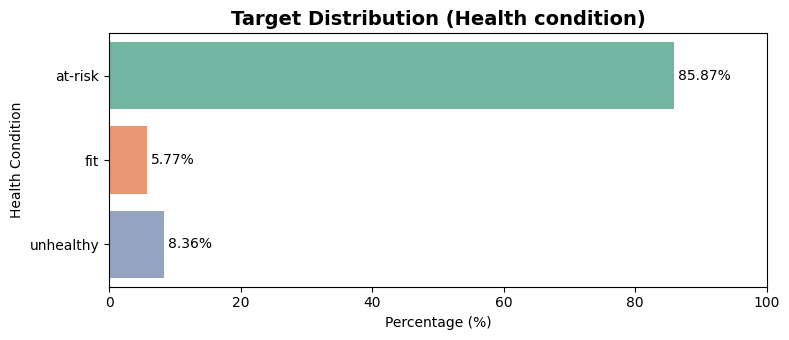

In [20]:
target_pct = (df['health_condition'].value_counts(normalize=True) * 100).reset_index()
target_pct.columns = ['health_condition', 'percentage']

plt.figure(figsize=(8,3.5))
ax = sns.barplot(
    data=target_pct,
    y='health_condition',
    x='percentage',
    palette="Set2",
    hue='health_condition',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.title("Target Distribution (Health condition)", fontsize=14, fontweight='bold')
plt.xlabel("Percentage (%)")
plt.ylabel("Health Condition")
plt.xlim(0,100)
plt.tight_layout()
plt.show()

#### **Target Class Imbalance & Metric Impact**

* **Severe Class Imbalance:** The target variable (`health_condition`) has an extreme class distribution of roughly **85 : 9 : 6**:
    * **`at-risk`**: ~85.3% (Majority)
    * **`unhealthy`**: ~8.8% (Minority)
    * **`fit`**: ~5.8% (Minority)


* **Why Accuracy is Misleading:**
A naive baseline model predicting `at-risk` 100% of the time would achieve a high standard accuracy of **~85%**, despite completely failing to identify any healthy or unhealthy students.

* **The Power of `balanced_accuracy`:**
Because the competition evaluates on **`balanced_accuracy`**, each class contributes equally. That same dummy model yields a score of **only 33.3% ($0.33$)**

* **Modeling Strategy:** Standard accuracy will be a false indicator of progress. Models must focus on minority class recall through class weighting, threshold adjustment, or resampling techniques to maximize balanced accuracy.

#### **Key Strategy Insights**

* **Class-Normalized EDA (Imbalance vs. Scarcity):**
This is a **class imbalance problem, not a data scarcity problem** (~40k–60k rows exist for minority classes). All feature plots must be class-normalized ($P(\text{feature} \mid \text{class})$) or target-rate binned so the ~85% `at-risk` majority doesn't mask minority patterns.

* **Minority Separation & Ordinal Structure:**
Since `fit` and `unhealthy` carry two-thirds ($66.7\%$) of the `balanced_accuracy` metric, EDA must focus strictly on features that separate `fit` from `unhealthy`. Additionally, the target has a natural ordinal severity scale ($\text{fit} \rightarrow \text{at-risk} \rightarrow \text{unhealthy}$), serving as a key modeling lever.

## Numerical - Univariate Analysis

In [21]:
quantative

['sleep_duration',
 'heart_rate',
 'bmi',
 'calorie_expenditure',
 'step_count',
 'exercise_duration',
 'water_intake']

In [22]:
num_df = df[quantative].melt()

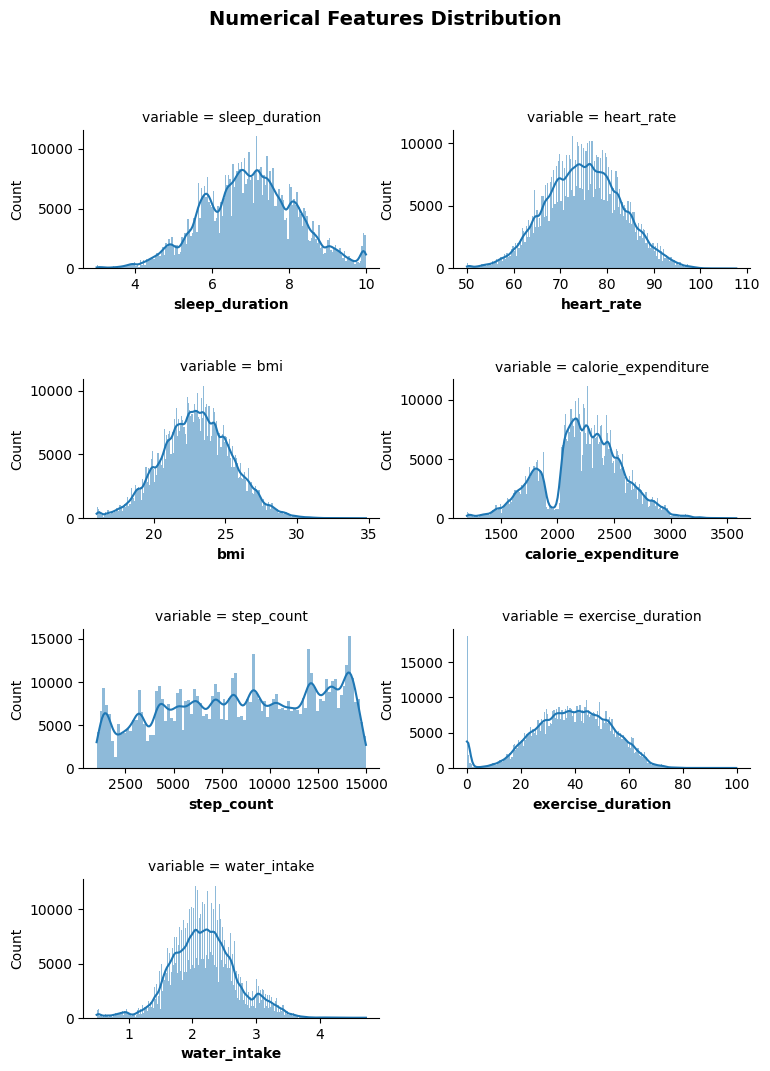

In [23]:
g = sns.displot(
    data=num_df,
    x='value',
    col='variable',
    col_wrap=2,
    kind='hist',
    kde=True,
    common_bins=False,
    facet_kws={'sharex': False, 'sharey': False},
    height=3,
    aspect=1.3
)

for ax, col_name in zip(g.axes.flat, num_df["variable"].unique()):
    ax.set_xlabel(col_name, fontsize=10, fontweight="bold")
    ax.set_ylabel("Count", fontsize=10)


plt.subplots_adjust(top=0.82, bottom=0.08, hspace=0.8, wspace=0.25)
g.fig.suptitle("Numerical Features Distribution", fontsize=14, fontweight="bold", y=0.92)
plt.show()

#### Univariate Analysis Insights

* `heart_rate` & `bmi` (near-normal & skewed):
    * `heart_rate` follows a near-perfect bell curve centered around `~75 bpm`.
    * `bmi` is unimodal centered around `~23`, exhibiting a moderate right tail extending up to `35`.


* `calorie_expenditure` has a bimodal distribution and exhibits two distinct clusters: a minor peak near `~1,700 kcal` and a major peak near `~2,250 kcal`, separated by a sharp drop at `~1,900 kcal`.


* `step_count` has a multi-spike / comb pattern distribution and displays a highly multimodal, comb-like distribution with regularly spaced sharp spikes across the `2,000–15,000` step range—a classic signature of synthetic data generation.


* `sleep_duration` & `water_intake` (bounded & mode-centered): `sleep_duration` concentrates heavily in the `6–8 hour` range with boundary spikes visible at `10 hours`, while `water_intake` is right-skewed, peaking sharply between `2.0–2.5 L/day`.

* `exercise_duration` (zero-inflation & boundary artifacts): While non-zero values follow a smooth normal curve centered around `~40 mins`, there is a massive point mass (spike) at `0 minutes`.

## Numerical - Bivariate Analysis - Visual

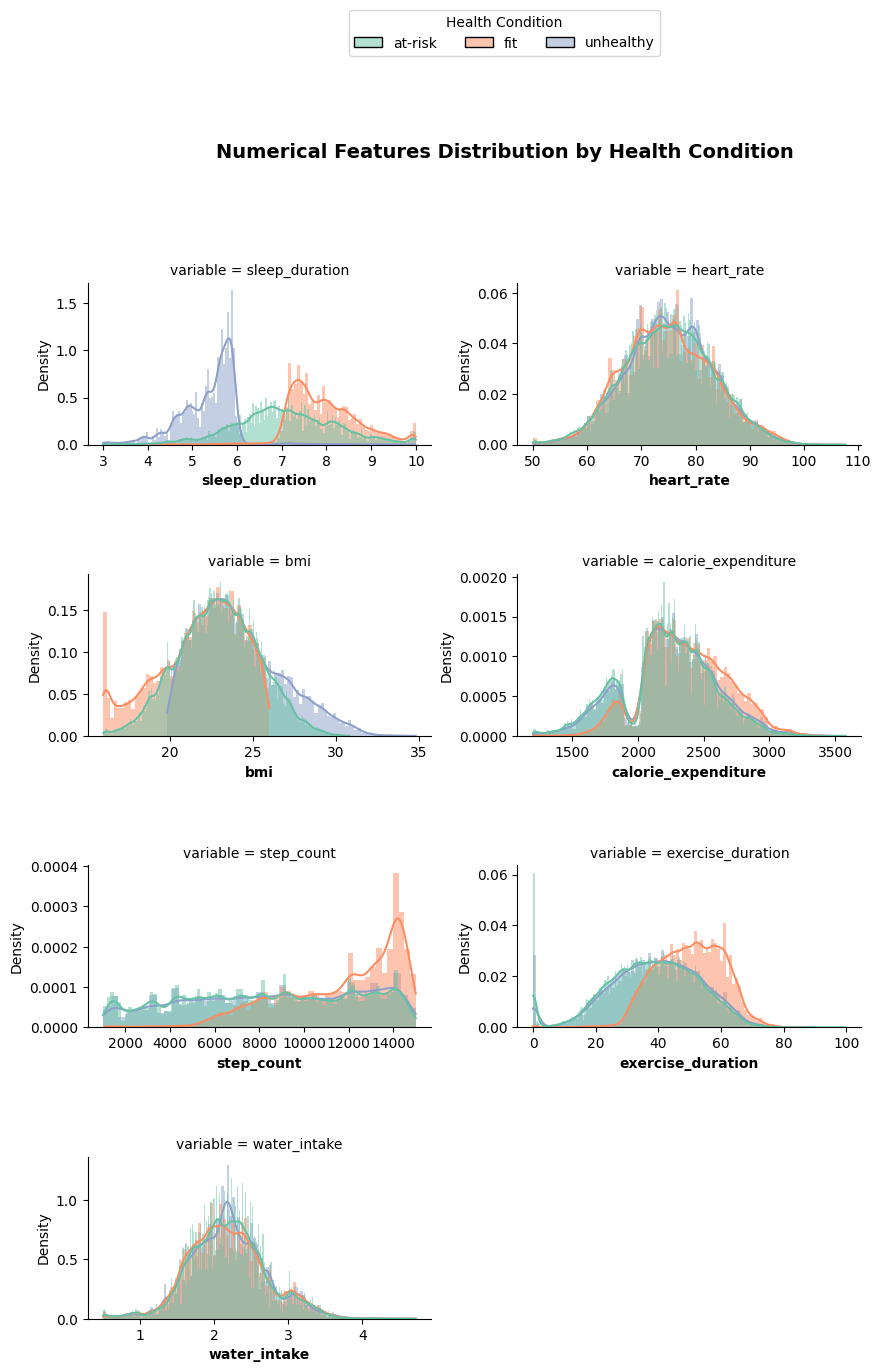

In [24]:
num_bivar_df = df[quantative + ["health_condition"]].melt(id_vars="health_condition")

g = sns.displot(
    data=num_bivar_df,
    x="value",
    hue="health_condition",
    col="variable",
    col_wrap=2,
    kind="hist",
    kde=True,
    common_bins=False,
    stat="density",
    common_norm=False,
    facet_kws={"sharex":False,"sharey":False},
    height=3.5,
    aspect=1.3,
    palette="Set2"
)

for ax, col_name in zip(g.axes.flat, num_bivar_df["variable"].unique()):
    ax.set_xlabel(col_name, fontsize=10, fontweight="bold")
    ax.set_ylabel("Density", fontsize=10)

sns.move_legend(
    g,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    title="Health Condition",
    frameon=True,
)

plt.subplots_adjust(top=0.82, bottom=0.08, hspace=0.8, wspace=0.25)
g.fig.suptitle("Numerical Features Distribution by Health Condition", fontsize=14, fontweight="bold", y=0.92)
plt.show()

Here is the updated text with all references changed to `fit` students:

#### Bivariate Analysis Insights

* `sleep_duration` shows the strongest, near-perfect ordinal separation across classes: `unhealthy` peaks lowest (`~5.2h`), `at-risk` sits in the middle (`~6.9h`), and `fit` reaches highest (`~7.8h`).

* `exercise_duration` & `step_count` reveal that `fit` students shift noticeably toward higher values (more exercise/steps), while `at-risk` and `unhealthy` distributions heavily overlap.

* `bmi` exhibits a strong right-skewed separation where `unhealthy` students dominate the higher BMI range (>26), while `fit` students concentrate on the lower, fitter BMI side (<22).

* `calorie_expenditure` shows a bimodal structure where `fit` students shift toward the higher expenditure peak (`~2,400+ kcal`), whereas `unhealthy` students lean toward lower caloric burn (`~1,700 kcal`).

* `heart_rate` & `water_intake` show virtually identical distributions across all three health conditions, providing almost no clear linear separation on their own.

## Numerical - Bivariate Analysis - Metrics

### Eta-Squared ($\eta^2$) 

**Eta-squared ($\eta^2$)** measures the proportion of total variance in a numerical feature that is explained by a categorical target variable. It serves as an ANOVA-based effect size metric to evaluate feature importance in classification tasks.

$$\eta^2 = \frac{SS_{\text{between}}}{SS_{\text{total}}}$$

**Interpretation Benchmarks:**

* **$\eta^2 < 0.01$ (Negligible):** Feature distributions overlap heavily across classes, offering minimal predictive value.
* **$0.01 \le \eta^2 < 0.14$ (Small to Medium):** Feature shows weak to moderate separation between target classes.
* **$\eta^2 \ge 0.14$ (Large):** Feature strongly separates target classes, making it a key predictor for classification models.

**The one idea:** $\eta^2$ asks "how much of the target's variance is explained by knowing which group a row belongs to?" It's a ratio from 0 to 1.

In [25]:
def eta_square(feature, target= "health_condition"):
    grand_mean = df[feature].mean()
    ss_total = ((df[feature] - grand_mean)**2).sum()
    
    grouped = df.groupby(target, observed=False)[feature]
    ss_between = (grouped.count() * (grouped.mean() - grand_mean) ** 2).sum()

    return ss_between / ss_total

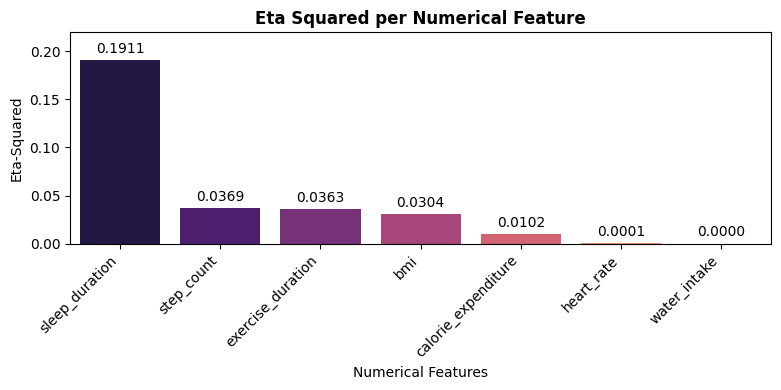

In [26]:
eta_scores = pd.Series({col: eta_square(col) for col in quantative}).sort_values(ascending=False)

plt.figure(figsize=(8,4))
ax = sns.barplot(x=eta_scores.index, y=eta_scores.values, palette="magma", hue=eta_scores.index, legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
    
plt.title("Eta Squared per Numerical Feature", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, eta_scores.max() * 1.15)
plt.ylabel("Eta-Squared")
plt.xlabel("Numerical Features")
plt.tight_layout()
plt.show()

#### **$\eta^2$ Summary:**

* `sleep_duration` is the strong Predictor ($\eta^2 \approx 0.19$). It shows clear mean differences across all target classes, making it the most significant linear feature.
* `water_intake` and `heart_rate` are Non-Predictive ($\eta^2 \approx 0.00$) and have nearly identical means across all categories, offering zero linear separation.
* **Moderate Predictors ($\eta^2 \approx 0.01\text{--}0.04$):**
    * `bmi` shifts across both tails (`fit` lower, `unhealthy` higher).
    * `step_count`, `exercise_duration`, and `calorie_expenditure` are driven by a single class shifting away from the group mean.

### Mutual Information ($MI$) 

**Mutual Information ($MI$)** measures how much information a feature provides about a target variable by quantifying the reduction in uncertainty (entropy). Unlike linear metrics, it captures both **linear and non-linear** relationships between numerical features and categorical targets.

$$I(X; Y) = H(Y) - H(Y \mid X)$$

**Interpretation Benchmarks:**

* **$MI = 0$ (Independent):** Knowing the feature provides no information about the target.
* **$0 < MI < 0.1$ (Weak):** Feature provides slight predictive information.
* **$0.1 \le MI < 0.3$ (Moderate):** Feature noticeably reduces uncertainty about target classes.
* **$MI \ge 0.3$ (Strong):** Feature strongly informs target prediction and captures complex dependency patterns.

**Note:** These thresholds are relative. MI score magnitudes are heavily influenced by dataset size and the number of features. In large datasets (like this one with ~690,000 rows), MI scores naturally compress downward, meaning a "moderate" score (e.g., 0.15) can actually represent a massive and highly significant predictive signal.

**Core idea:** MI asks "how much does knowing this feature reduce my uncertainty about the target?" Measured in bits/nats of uncertainty removed.

**Why MI beats $\eta^2$ :**

$\eta^2$ only sees whether class means differ. MI sees any dependence like bimodal, U-shaped, "class fit lives at both extremes." If a feature separates classes by shape rather than location, $\eta^2$ reads 0 and MI does not. That's the whole reason to run both.

**Why Pairwise Deletion?**

* **Maximizes Sample Size:** Retains the maximum amount of valid data for each individual feature instead of discarding rows missing unrelated variables.
* **Preserves Pure Signal:** Evaluates true feature-target relationships accurately without introducing noise or bias from early imputation.

In [27]:
from sklearn.feature_selection import mutual_info_classif

def calculate_mi_scores(df, features, target_col="health_condition"):
    mi_scores = {}

    # pairwise Deletion 
    for col in features:
        pair_df = df[[col, target_col]].dropna()
        X_pair = pair_df[[col]]
        y_pair = pair_df[target_col]

        score = mutual_info_classif(X_pair, y_pair, n_neighbors=5, random_state=42)[0]
        mi_scores[col] = score
    
    return pd.Series(mi_scores).sort_values(ascending=False) 

mi_series = calculate_mi_scores(df, quantative)

#### Mutual Information Noise floor:

* **The Problem:** Mutual Information algorithms rarely output exactly `0.0`. Due to mathematical noise, completely unrelated data will still generate small positive scores (like 0.0085).
* **The Solution (Permutation Nulls):** Randomly shuffling the target variable (`y`) destroys any real pattern.
* **The Rule:** If you compute MI on this shuffled data, the resulting scores represent "pure noise". If your feature's actual MI score is below or within this noise range, the feature is statistically meaningless.


In [28]:
def get_mi_noise_floor(df, features, target_col="health_condition", n_repeats=5):
    max_noise_score = {}

    for col in features:
        pair_df = df[[col,target_col]].dropna()
        X_pair = pair_df[[col]]
        y_pair = pair_df[target_col]

        col_noise = []
        for i in range(n_repeats):
            y_shuffled = np.random.permutation(y_pair)
            score = mutual_info_classif(X_pair, y_pair, n_neighbors=5, random_state=i)[0]
            col_noise.append(score)
        
        max_noise_score[col] = np.max(col_noise)
    return pd.Series(max_noise_score).sort_values(ascending=False)

noise_thresholds = get_mi_noise_floor(df, quantative, n_repeats=5)

print("Noise Floor Thresholds:")
print(noise_thresholds)

Noise Floor Thresholds:
sleep_duration         0.173087
bmi                    0.032460
exercise_duration      0.023460
step_count             0.023109
water_intake           0.009171
calorie_expenditure    0.007366
heart_rate             0.004496
dtype: float64



Valid Features:
sleep_duration         False
bmi                    False
exercise_duration      False
step_count             False
water_intake           False
calorie_expenditure    False
heart_rate             False
dtype: bool


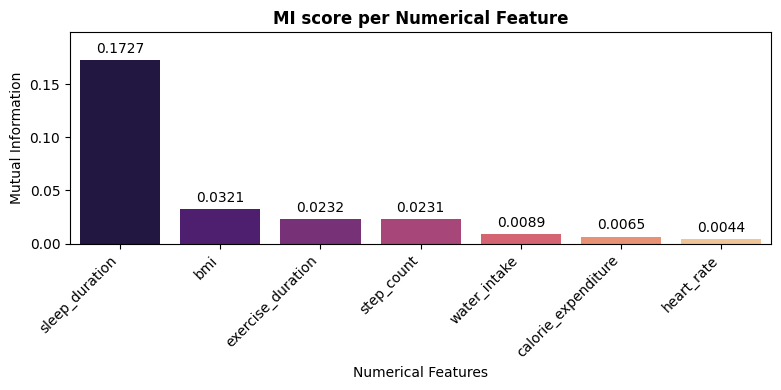

In [29]:
real_signal = mi_series > noise_thresholds
print("\nValid Features:")
print(real_signal)


plt.figure(figsize=(8,4))
ax = sns.barplot(x=mi_series.index, y=mi_series.values, palette="magma", hue=mi_series.index, legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
    
plt.title("MI score per Numerical Feature", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, mi_series.values.max() * 1.15)
plt.ylabel("Mutual Information")
plt.xlabel("Numerical Features")
plt.tight_layout()
plt.show()

#### **MI plot Summary:**

* **Strongest Signal:** `sleep_duration` is by far the most informative numerical feature (MI = 0.1727), indicating a strong relationship with the target.
* **Moderate Signal:** `bmi` (0.0321), `exercise_duration` (0.0232), and `step_count` (0.0231) provide weak but meaningful predictive value.
* **Weakest Signal:** `water_intake`, `calorie_expenditure`, and `heart_rate` have near-zero scores (< 0.01), offering negligible predictive power on their own.

## Numerical - Correlation Analysis

Note: **Spearman correlation** makes the most sense for this dataset.

* **Non-Normal Distributions:** Features like `step_count` (comb-like/multimodal), `calorie_expenditure` (bimodal), and `exercise_duration` (zero-inflated mass at 0) violate Pearson's normality assumption.
* **Non-Linear Relationships:** Spearman captures monotonic trends (variables moving together) even when the relationship is non-linear or stepped.
* **Outlier & Artifact Robustness:** It relies on ranks rather than raw values, making it immune to extreme boundary spikes (like `sleep_duration` capped at 10 or `water_intake`).

Note: `np.triu` Hides redundant duplicate correlations on the upper triangle.

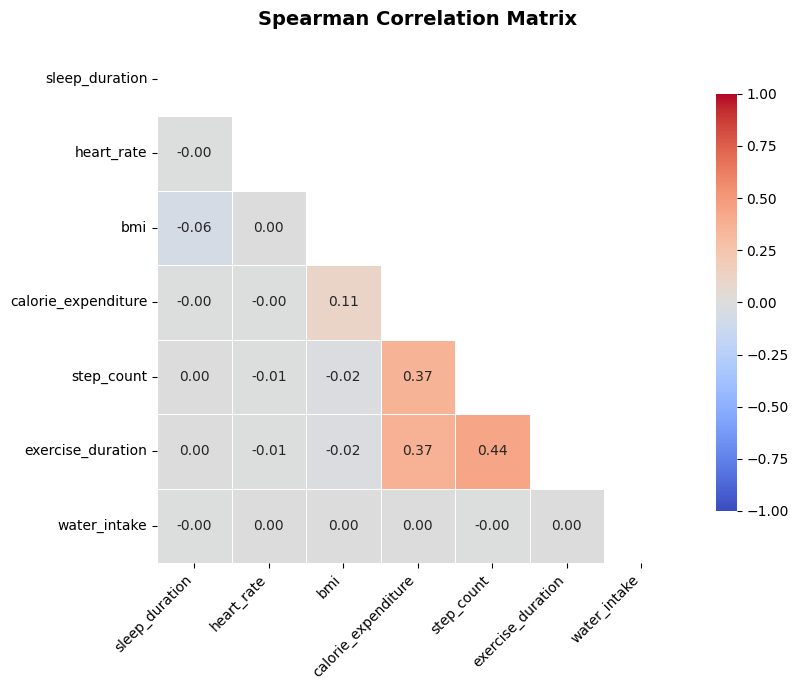

In [30]:
corr_matrix = df[quantative].corr(method="spearman")

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Spearman Correlation Matrix", fontsize=14, fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Quantiative features - Correlation Summary:**

* `water_intake` and `heart_rate` show zero correlation with all other numerical features. Combined with their near-zero Mutual Information scores, these features provide virtually no predictive signal and are strong candidates for removal.
* `bmi` exhibits a very weak positive correlation with `calorie_expenditure` (0.11). However, it remains a valuable independent predictor based on its moderate MI score.
* The physical activity metrics (`step_count`, `calorie_expenditure`, and `exercise_duration`) share moderate positive correlations with each other (ranging from 0.37 to 0.44), which aligns with expected physical behavior.
* `sleep_duration` shows zero correlation with all other numerical features. This is a critical insight: its strong predictive power (the highest MI score) is entirely independent of the other physical metrics.
* There is no severe multicollinearity among these numerical features. The highest observed correlation is 0.44, well below standard thresholds (e.g., 0.7+), meaning no features need to be dropped due to redundancy.

## Categorical - Univariate Analysis

In [31]:
qualitative

['diet_type',
 'stress_level',
 'sleep_quality',
 'physical_activity_level',
 'smoking_alcohol',
 'gender']

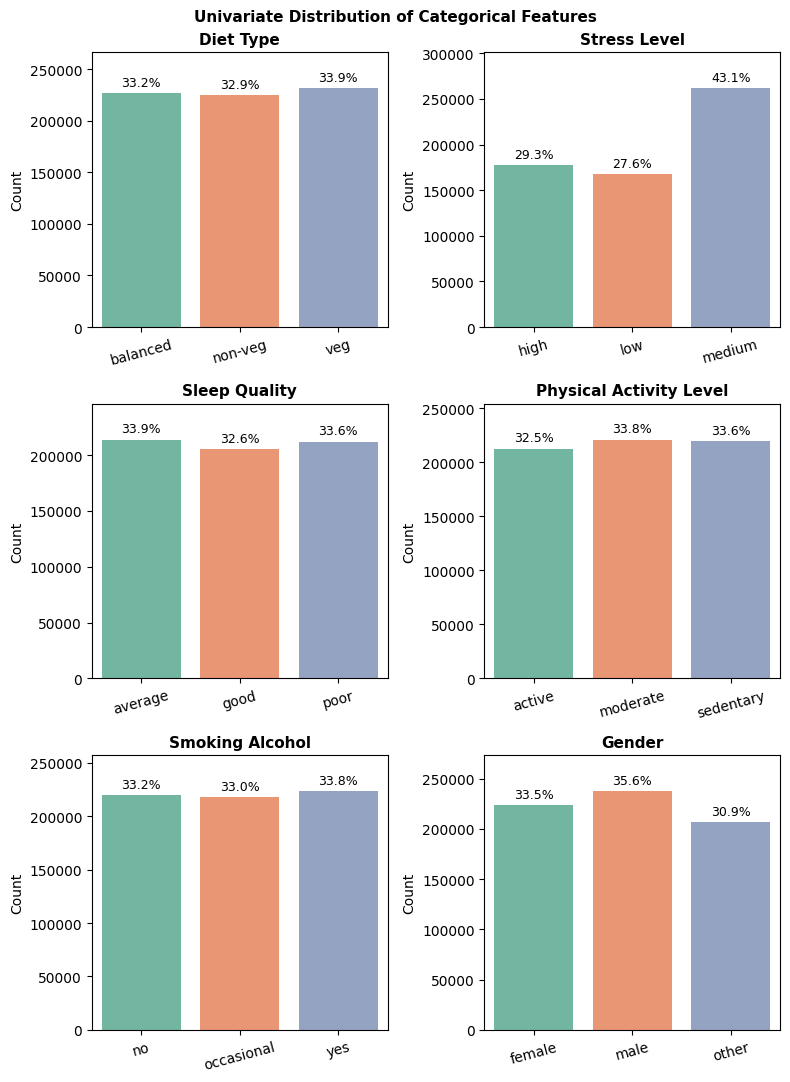

In [32]:
fig, axes = plt.subplots(3,2, figsize=(8,11))
axes = axes.flatten()

for ax, col in zip(axes, qualitative):
    sns.countplot(data=df, x=col, ax=ax, palette="Set2", hue=col, legend=False)

    total = len(df[col].dropna())
    max_height = 0 
    for p in ax.patches:
        height = p.get_height()
        if max_height < height:
            max_height = height
            
        if height > 0:
            pct = f"{(height/total)*100:.1f}%"
            ax.annotate(pct, (p.get_x()+p.get_width()/ 2., height),
                       ha="center", va="bottom", fontsize=9, xytext=(0,3),
                       textcoords=("offset points"))
    
    ax.set_title(col.replace("_"," ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.set_ylim(0,max_height*1.15)
    ax.tick_params(axis="x", rotation=15)

plt.subplots_adjust(hspace=0.6, wspace=0.4)
plt.suptitle("Univariate Distribution of Categorical Features", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

#### **Gini Impurity:**

It measures the degree of randomness or class mixing within a set of data points. It quantifies how often a randomly chosen element from the set would be incorrectly labeled if it were randomly labeled according to the distribution of labels in the subset.


**Formula:**

$$Gini = 1 - \sum_{i=1}^{k} p_i^2$$

(where $p_i$ is the proportion of samples belonging to target class $i$, and $k$ is the total number of classes)

In [33]:
def calc_GI(vals, total):
    gi = 1 
    for v in vals:
        gi -= (v/total)**2
    return gi

def calc_Gini_impurity(df, features):
    result = {}
    for col in features:
        vals = df[col].value_counts()
        total = vals.sum()
        result[col] = calc_GI(vals, total)
    return pd.DataFrame(result.items(), columns=["features", "Gini_Impurity"])

print(f"\nMax possible Gini Impurity for 3 class: {calc_GI([1/3, 1/3, 1/3], 1):.5f} \n")

calc_Gini_impurity(df, qualitative)


Max possible Gini Impurity for 3 class: 0.66667 



,features,Gini_Impurity
0,diet_type,0.666618
1,stress_level,0.652182
2,sleep_quality,0.666571
3,physical_activity_level,0.666571
4,smoking_alcohol,0.666627
5,gender,0.665601


#### **Summary of Categorical Univariate Analysis:**

- Near perfect Uniform distribution for every categorical feature contains exactly 3 categories, each accounting for roughly $~33.3%$ of the dataset ($~210k–230k$ rows per category). This extreme balance across all categories is a strong signature of synthetic data generation.
- Maximum Gini Impurity ($\approx 0.66$): Quantifying feature diversity via Gini Impurity yields values between $0.652$ and $0.666$ across all qualitative features. For a 3-category variable, the maximum theoretical Gini Impurity is $0.667$. This confirms complete entropy/randomness at the univariate level, with no rare or dominant categories.
- Since there are no low-frequency or rare categories (no sparse categories to collapse), standard One-Hot Encoding (OHE) or Ordinal Encoding can be safely applied without memory issues or data-leakage risks.

## Categorical - Bivariate Analysis

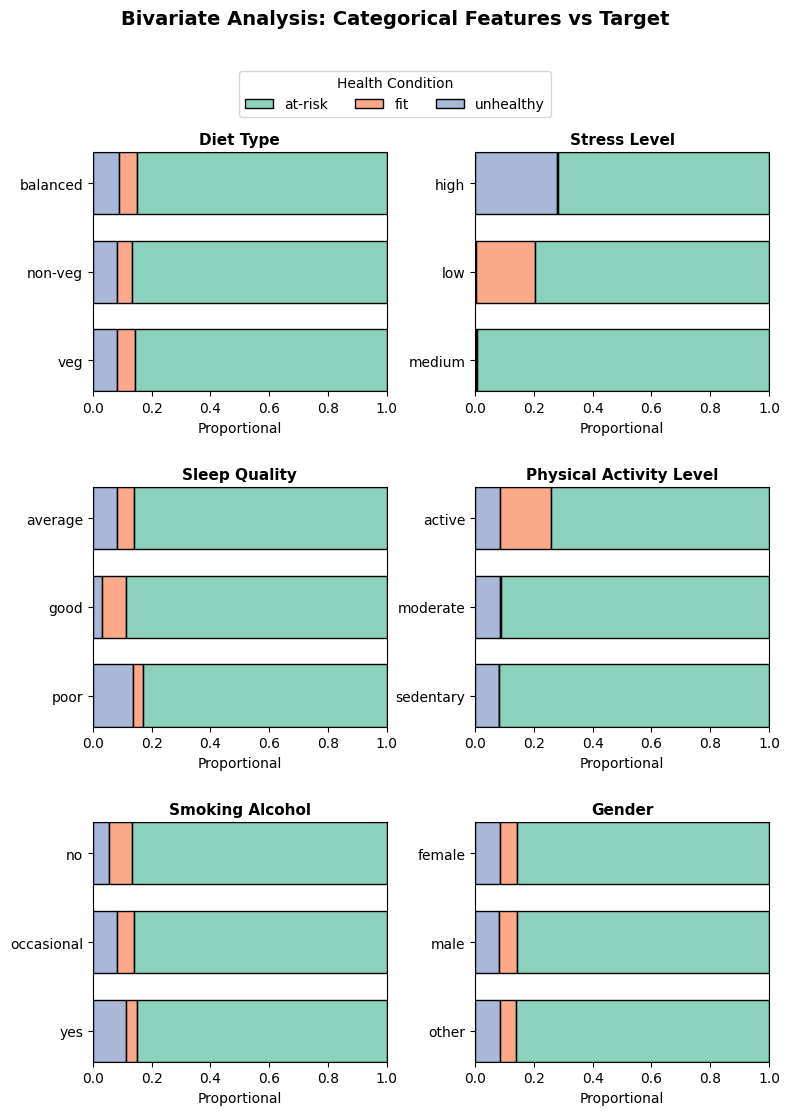

In [34]:
fig, axes = plt.subplots(3, 2, figsize=(8,11))
axes = axes.flatten()

for ax, col in zip(axes, qualitative):
    sns.histplot(
        data=df,
        y=col,
        hue="health_condition",
        multiple="fill",
        stat="probability",
        shrink=0.7,
        palette="Set2",
        ax=ax,
        discrete=True
    )
    
    ax.set_title(col.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_ylabel("")
    ax.set_xlabel("Proportional")


handles = axes[0].get_legend().legend_handles
labels = [t.get_text() for t in axes[0].get_legend().get_texts()]

for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

fig.legend(
    handles, 
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96), 
    ncol=3, 
    title="Health Condition",
    frameon=True
)

plt.suptitle("Bivariate Analysis: Categorical Features vs Target", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.4, wspace=0.3)
plt.show()

#### **Weighted Average Gini Impurity for Categorical Features:**

A categorical feature (e.g., `diet_type`) splits the dataset into distinct sub-groups (e.g., `veg, balanced, non-veg`). Each sub-group has its own target class distribution and individual Gini Impurity. To evaluate how well the feature as a whole separates the target classes, we take the weighted average of the sub-groups' Gini Impurities. Weighting by sample count ($N_j$) ensures that larger categories have a proportionally higher impact on the metric than tiny categories.

**Formula:**

$$\text{Weighted Gini} = \sum_{j=1}^{M} \left( \frac{N_j}{N_{\text{total}}} \times Gini_j \right)$$

*(where $M$ is the number of categories in the feature, $N_j$ is the row count of category $j$, $N_{\text{total}}$ is the total dataset row count, and $Gini_j$ is the Gini Impurity of category $j$)*

#### **Gini Gain** 

It's also called Information Gain via Gini and It measures how much target uncertainty is **reduced** after splitting the data by a given categorical feature.

$$\text{Gini Gain} = Gini_{\text{overall target}} - \text{Weighted Gini}_{\text{feature}}$$

#### How to Interpret Gini Gain

* **High Positive Value (Purest Split):** **Strong predictive power.** Splitting by this feature significantly drops target impurity, creating distinct, uniform sub-groups that tree models prioritize.

* **Zero ($0.0$):** **No predictive power.** The weighted feature Gini equals the overall target Gini, meaning the feature split provides zero useful information.

* **Negative Value (Impurest Split):** **Worse separation.** Indicates that splitting actually increases uncertainty or dilutes class clarity compared to the unsplit dataset (tree models will reject these splits).

In [35]:
target_props = df["health_condition"].value_counts(normalize=True)
overall_target_gini = float(1 - (target_props ** 2).sum())

print(
    f"Target Gini Impurity (Baseline): {overall_target_gini:.4f}\n",
    f"Context: Low baseline (~0.252 vs max 0.667) reflects severe class imbalance (~85% at-risk)."
)

Target Gini Impurity (Baseline): 0.2524
 Context: Low baseline (~0.252 vs max 0.667) reflects severe class imbalance (~85% at-risk).


In [36]:
def categorical_Gini_Impurity(df, features, target="health_condition"):
    result = {}
    for feature in features:
        clear_df = df[[feature, target]].dropna()
        counts = pd.crosstab(clear_df[feature],clear_df[target])
        category_counts = counts.sum(axis=1)
        proportions = counts.div(counts.sum(axis=1), axis=0)
        
        gini_series = 1 - (proportions ** 2).sum(axis=1)
        result[feature] = np.average(gini_series, weights=category_counts)

    return pd.DataFrame(result.items(), columns=["features", "weighted_avg"])

categorical_gini = categorical_Gini_Impurity(df, qualitative)
categorical_gini["gini_gain"] = overall_target_gini - categorical_gini["weighted_avg"]
categorical_gini

,features,weighted_avg,gini_gain
0,diet_type,0.252424,-0.000070
1,stress_level,0.214132,0.038223
2,sleep_quality,0.249726,0.002628
3,physical_activity_level,0.239711,0.012643
4,smoking_alcohol,0.251346,0.001008
5,gender,0.252312,0.000042


**Note:** A tiny negative on `diet_type` like −0.00004 isn't a bug, it's floating-point rounding. `diet_type`'s true gain is essentially zero (weighted_avg ≈ baseline to 4+ decimals), so the subtraction lands a hair below zero. 

#### **Categorical Bivariate Analysis Summary:**


* **Dominant Categorical Driver (`stress_level` ~0.038):** `stress_level` is by far the strongest qualitative predictor. Its high Gini Gain confirms that splitting students by stress tiers creates the sharpest separation across `fit`, `at-risk`, and `unhealthy` target classes.

* **Secondary Signal (`physical_activity_level` ~0.010):** `physical_activity_level` provides a moderate, meaningful contribution to target separation, making it the second most informative categorical feature.

* **Marginal Predictors (`sleep_quality` ~0.002 & `smoking_alcohol` ~0.001):** Both features exhibit very minor Gini Gain, showing minimal variance in target proportions across categories. While weak individually, tree algorithms may still utilize them in multi-feature interactions.

* **Uninformative Noise (`diet_type` & `gender` ~0.000):** Both features yield a Gini Gain of virtually zero. This confirms what the horizontal stacked bar plots showed: target class proportions are completely identical across categories, offering zero direct predictive power.

* **Modeling Takeaway:** Decision tree models (LightGBM, XGBoost, CatBoost) will heavily favor `stress_level` and `physical_activity_level` for early node splits. Zero-gain features like `diet_type` and `gender` can be flagged for potential removal during feature selection to reduce model dimensionality and noise.

## Categorical - Mutual Information Analysis

In [37]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

mi_df = df[qualitative + ["health_condition"]].dropna().copy()

X_encoded = OrdinalEncoder().fit_transform(mi_df[qualitative]) # no specific order 
y_encoded = LabelEncoder().fit_transform(mi_df["health_condition"])

mi_scores = mutual_info_classif(
    X_encoded,
    y_encoded,
    discrete_features=True, # for categorical data
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": qualitative,
    "Mutual_Information": mi_scores
}).sort_values(by="Mutual_Information", ascending=False).reset_index(drop=True)

mi_results

,Feature,Mutual_Information
0,stress_level,0.161748
1,physical_activity_level,0.059070
2,sleep_quality,0.015370
3,smoking_alcohol,0.006452
4,diet_type,0.000229
5,gender,0.000163


In [38]:
def get_category_mi_noise_floor(data, features, target_col="health_condition", n_repeats=5):
    max_noise_score = {}

    X_all = OrdinalEncoder().fit_transform(data[features])
    y_all = LabelEncoder().fit_transform(data[target_col])

    for i, col in enumerate(features):
        X_col = X_all[:, [i]]

        col_noise = []
        for seed in range(n_repeats):
            np.random.seed(seed)
            y_shuffled = np.random.permutation(y_all)
            
            score = mutual_info_classif(X_col, y_shuffled, n_neighbors=5, random_state=seed)[0]
            col_noise.append(score)
        
        max_noise_score[col] = np.max(col_noise)
    return pd.Series(max_noise_score).sort_values(ascending=False)

noise_thresholds = get_category_mi_noise_floor(mi_df, qualitative, n_repeats=5)

print("Noise Floor Thresholds:")
print(noise_thresholds)

Noise Floor Thresholds:
stress_level               0.020452
smoking_alcohol            0.017513
sleep_quality              0.016980
diet_type                  0.016694
physical_activity_level    0.016657
gender                     0.015407
dtype: float64


Valid Categorical Features (MI > Noise Threshold):
                   Feature  Mutual_Information  Noise_Threshold  Is_Valid
0             stress_level            0.161748         0.020452      True
1  physical_activity_level            0.059070         0.016657      True
2            sleep_quality            0.015370         0.016980     False
3          smoking_alcohol            0.006452         0.017513     False
4                diet_type            0.000229         0.016694     False
5                   gender            0.000163         0.015407     False


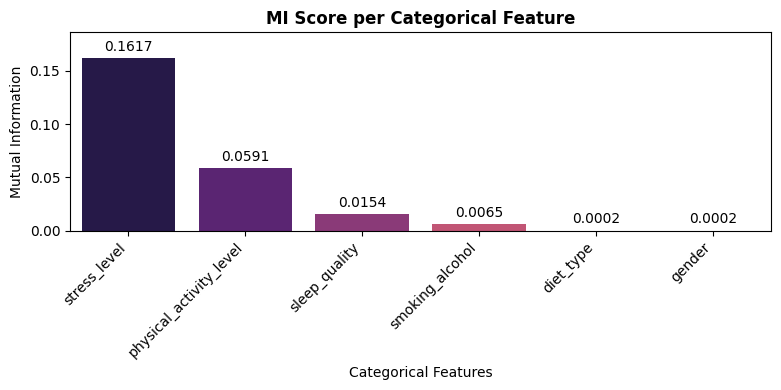

In [39]:
mi_results["Noise_Threshold"] = mi_results["Feature"].map(noise_thresholds)
mi_results["Is_Valid"] = mi_results["Mutual_Information"] > mi_results["Noise_Threshold"]

print("Valid Categorical Features (MI > Noise Threshold):")
print(mi_results[["Feature", "Mutual_Information", "Noise_Threshold", "Is_Valid"]])

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=mi_results, 
    x="Feature", 
    y="Mutual_Information", 
    palette="magma", 
    hue="Feature", 
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("MI Score per Categorical Feature", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, mi_results["Mutual_Information"].max() * 1.15)
plt.ylabel("Mutual Information")
plt.xlabel("Categorical Features")
plt.tight_layout()
plt.show()

#### **Mutual Information Analysis of Categorical Data:**


* **Dominant Valid Signal (`stress_level` ~0.1617):** `stress_level` is by far the strongest categorical feature, exceeding its noise floor (`~0.0205`) by nearly $8\times$. It provides substantial predictive power for separating student target classes.

* **Moderate Valid Signal (`physical_activity_level` ~0.0591):** `physical_activity_level` is the only other qualitative feature with a statistically valid signal, comfortably clearing its noise threshold (~0.0167) to serve as a reliable secondary predictor.

* **Weak & Invalid Signals (`sleep_quality` ~0.0154 & `smoking_alcohol` ~0.0065):** Although both features show non-zero raw MI scores, both fall **below** their respective permutation noise thresholds (~0.0170 and ~0.0175). Their apparent signal is statistically indistinguishable from random chance.

* **Complete Uninformative Noise (`diet_type` & `gender` ~0.0002):** Both features yield near-zero MI scores, failing their noise thresholds by a wide margin. Knowing a student's gender or diet type provides zero mutual information about their health risk tier.

* **Key Modeling Takeaway:** Out of all 6 qualitative features, **only two (`stress_level` and `physical_activity_level`) contain true, valid signal**. The remaining 4 features (`sleep_quality`, `smoking_alcohol`, `diet_type`, `gender`) fail the permutation noise test and are prime candidates for removal during feature selection to prevent model overfitting.

## Categorical - Cramer's V - Target Analysis

In [40]:
def calc_cramers_v(x,y):
    contingency_matrix = pd.crosstab(x,y)
    chi2, _, _, _ = chi2_contingency(contingency_matrix)
    n = contingency_matrix.sum().sum()

    r, c = contingency_matrix.shape
    k = min(r-1, c-1)
    if k == 0 :
        return 0.0

    return np.sqrt((chi2/n) / k)

## Categorical - Cramer's V - Bivariate Analysis

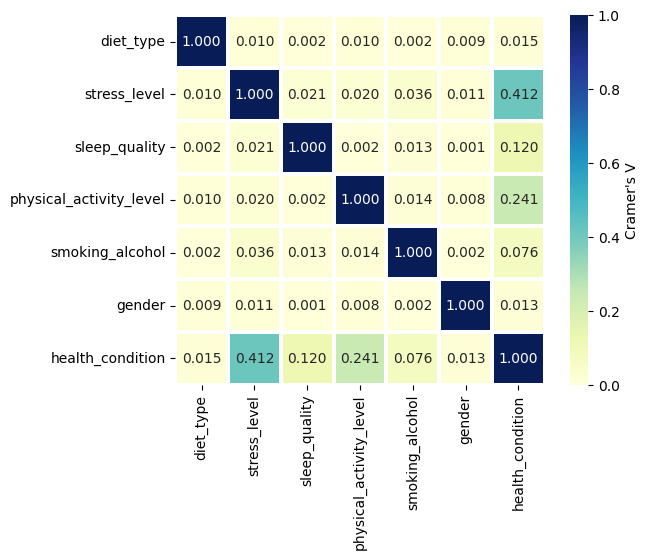

In [41]:
from scipy.stats import chi2_contingency

cv_feats = qualitative + ["health_condition"]
cramer_matrix = pd.DataFrame(1.0, index=cv_feats, columns=cv_feats)

for i in range(0, len(cv_feats)):
    for j in range(i):
        col_1 = cv_feats[i]
        col_2 = cv_feats[j]
        clean_pair = df[[col_1,col_2]].dropna()
        score = calc_cramers_v(clean_pair[col_1], clean_pair[col_2])
        cramer_matrix.loc[col_1,col_2] = score
        cramer_matrix.loc[col_2,col_1] = score
        
sns.heatmap(
    cramer_matrix,
    annot=True,
    fmt=".3f",
    linewidths=1.5,
    linecolor="white",
    vmin=0,
    vmax=1,
    square=True,
    cmap="YlGnBu",
    cbar_kws={"label": "Cramer's V"},
)
plt.show()

Text(0.5, 1.0, "Carmer's V - Categorical Features VS Target Analysis")

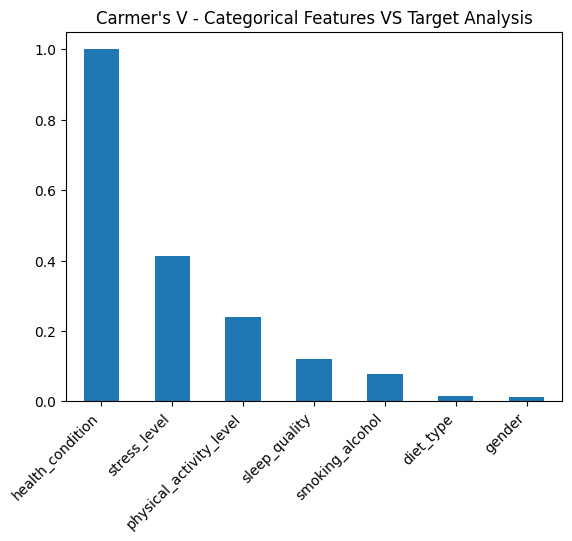

In [42]:
ax = cramer_matrix["health_condition"].sort_values(ascending=False).plot(kind="bar", rot=45)
plt.xticks(ha="right")
plt.title("Carmer's V - Categorical Features VS Target Analysis")

### **Problem: Large Sample Size ($N = 690\text{K}$)**

* **$\chi^2$ Over-Inflation:** Chi-Square ($\chi^2$) scales directly with $N$. At $N = 690,088$, $p$-values collapse to $0.000$ for nearly all feature pairs, rendering hypothesis testing ($p$-values) useless for feature selection.
* **Sensitivity to Noise & Artifacts:** With $690\text{K}$ rows, even tiny synthetic dataset artifacts or negligible group imbalances yield non-zero Cramér's V scores.
* **Standard Cramér's V Positive Bias:** Uncorrected Cramér's V inherently overestimates association strength, especially as contingency table dimensions ($r \times c$) grow.

### Use Bias-Corrected Cramér's V (Bergsma Method)

Subtracts the expected variance under independence to eliminate sample-size and dimension bias:

$$\tilde{V} = \sqrt{\frac{\max\left(0, \frac{\chi^2}{N} - \frac{(r-1)(c-1)}{N-1}\right)}{\min(\tilde{r}-1, \tilde{c}-1)}}$$

*(where $\tilde{r} = r - \frac{(r-1)^2}{N-1}$ and $\tilde{c} = c - \frac{(c-1)^2}{N-1}$)*

#### Establish a Permutation Noise Floor (Not Implemented)

Shuffle target labels $y$ (5–10 times) on the $690\text{K}$ dataset to measure the baseline score caused purely by random chance. Filter out any feature where:


$$\text{Cramér's V}_{\text{feature}} \le \text{Cramér's V}_{\text{noise\_floor}}$$


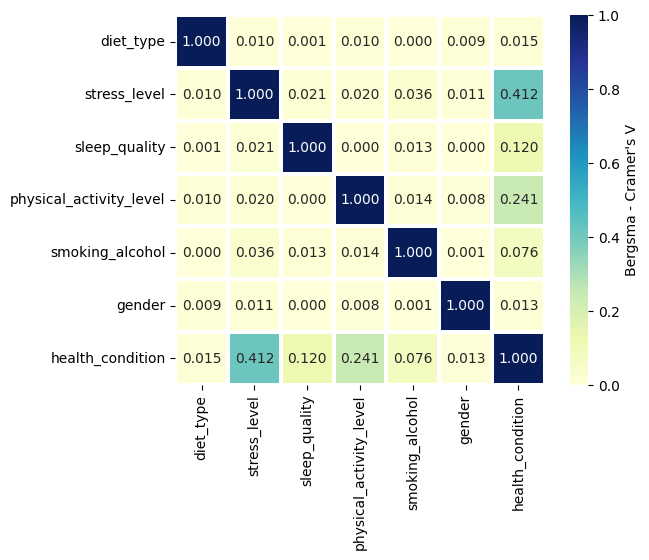

In [43]:
cramer_matrix_2 = pd.DataFrame(1.0, index=cv_feats, columns=cv_feats)

def calc_bergsma_cramers_v(x,y):
    contingency_matrix = pd.crosstab(x,y)
    chi2, _, _, _ = chi2_contingency(contingency_matrix)
    n = contingency_matrix.sum().sum()

    r, c = contingency_matrix.shape
    r_hat = r - ((r-1)**2 / (n-1))
    c_hat = c - ((c-1)**2 / (n-1))
    k = min(r_hat-1, c_hat-1)
    if k == 0 :
        return 0.0

    n1 = chi2 / n 
    n2 = ((r-1)*(c-1)) / (n-1)
    num = max(0, n1-n2)

    return np.sqrt(num/ k)


for i in range(1, len(cv_feats)):
    for j in range(i):
        col_1 = cv_feats[i]
        col_2 = cv_feats[j]
        clean_pair = df[[col_1,col_2]].dropna()
        score = calc_bergsma_cramers_v(clean_pair[col_1], clean_pair[col_2])
        cramer_matrix_2.loc[col_1,col_2] = score
        cramer_matrix_2.loc[col_2,col_1] = score
        
sns.heatmap(
    cramer_matrix_2,
    annot=True,
    fmt=".3f",
    linewidths=1.5,
    linecolor="white",
    vmin=0,
    vmax=1,
    square=True,
    cmap="YlGnBu",
    cbar_kws={"label": "Bergsma - Cramer's V"},
)
plt.show()

### Summary: Cramér’s V & Sample Size ($N = 690\text{K}$)

At large sample sizes ($N = 690,088$), standard Cramér’s $V$ and Bias-Corrected Cramér’s $V$ (Bergsma method) produce **virtually identical results** (matching up to 5 decimal places). Bias correction is designed for small sample sizes ($N < 1,000$) or high-cardinality features ($r, c \ge 50$), whereas a large $N$ naturally suppresses sample-size bias.

#### The Mathematical Calculation

The Bergsma bias correction subtracts an expected variance penalty from the mean square contingency ($\phi^2$):

$$\text{Penalty} = \frac{(r - 1)(c - 1)}{N - 1}$$

#### **Dataset Parameters:**

* **Row Categories ($r$):** $3$ (e.g., `high`, `medium`, `low`)
* **Column Classes ($c$):** $3$ (`fit`, `at-risk`, `unhealthy`)
* **Sample Size ($N$):** $690,088$

#### **Penalty Calculation:**

$$\text{Penalty} = \frac{(3 - 1)(3 - 1)}{690,088 - 1} = \frac{2 \times 2}{690,087} = \frac{4}{690,087} \approx \mathbf{0.0000058}$$

Because $N$ is in the denominator, dividing by $690\text{K}$ reduces the bias adjustment to **$\approx 0.0000058$**, making standard and bias-corrected Cramér's $V$ practically interchangeable.



### Permutation Noise Thresholding Overview

> **Permutation noise thresholding** randomly shuffles the target labels to establish the baseline Cramér's V score produced purely by chance. A feature contains a true, valid signal only if its actual Cramér's V score exceeds this random permutation threshold.

#### Why Perform Permutation Noise Thresholding After Cramér's V?

1. **Bias Correction Doesn't Eliminate Random Noise:**
Bias-corrected Cramér's V (Bergsma method) only adjusts for sample size and table dimensions ($r \times c$). At $N = 690\text{K}$, the mathematical bias penalty collapses to near zero ($\approx 0.0000058$), making standard and bias-corrected Cramér's V virtually identical. However, neither metric answers whether a low score (e.g., $V = 0.015$) represents a weak true signal or pure random chance.
2. **Large-Sample Sensitivity to Synthetic Artifacts:**
With $690\text{K}$ rows, even completely uninformative features or synthetic dataset artifacts will yield non-zero Cramér's V values. Without a permutation test, you risk mistaking random synthetic artifacts for genuine predictive signals.
3. **Empirical Benchmark for "Zero Signal":**
Target-shuffling destroys the true relationship while keeping the exact same feature distribution and sample size intact. It provides an empirical ground-truth baseline tailored specifically to your dataset.


In [44]:
def get_bivariate_noise_matrices(df, features, n_repeats=5):
    """
    Computes pairwise Cramér's V, Permutation Noise Floor, and Validity Mask
    for a list of categorical features.
    """
    n_feats = len(features)
    
    actual_matrix = pd.DataFrame(1.0, index=features, columns=features)
    noise_matrix = pd.DataFrame(0.0, index=features, columns=features)
    
    # Iterate through lower triangle only
    for i in range(n_feats):
        for j in range(i):
            col1, col2 = features[i], features[j]
            x1 = df[col1].values
            x2 = df[col2].values
            
            # Actual pairwise Cramér's V
            real_v = calc_cramers_v(x1, x2)
            actual_matrix.loc[col1, col2] = real_v
            actual_matrix.loc[col2, col1] = real_v
            
            # Permutation Noise Floor (shuffle x2)
            perm_scores = []
            for seed in range(n_repeats):
                np.random.seed(seed)
                x2_shuffled = np.random.permutation(x2)
                noise_v = calc_cramers_v(x1, x2_shuffled)
                perm_scores.append(noise_v)
                
            max_noise = np.max(perm_scores)
            noise_matrix.loc[col1, col2] = max_noise
            noise_matrix.loc[col2, col1] = max_noise

    # Create boolean mask for signals above noise floor
    valid_mask = actual_matrix > noise_matrix

    return actual_matrix, noise_matrix, valid_mask

actual_matrix, noise_matrix, valid_mask = get_bivariate_noise_matrices(
    df=mi_df, 
    features=cv_feats, 
    n_repeats=5
)

In [45]:
(valid_mask == False).sum().sum()

np.int64(8)

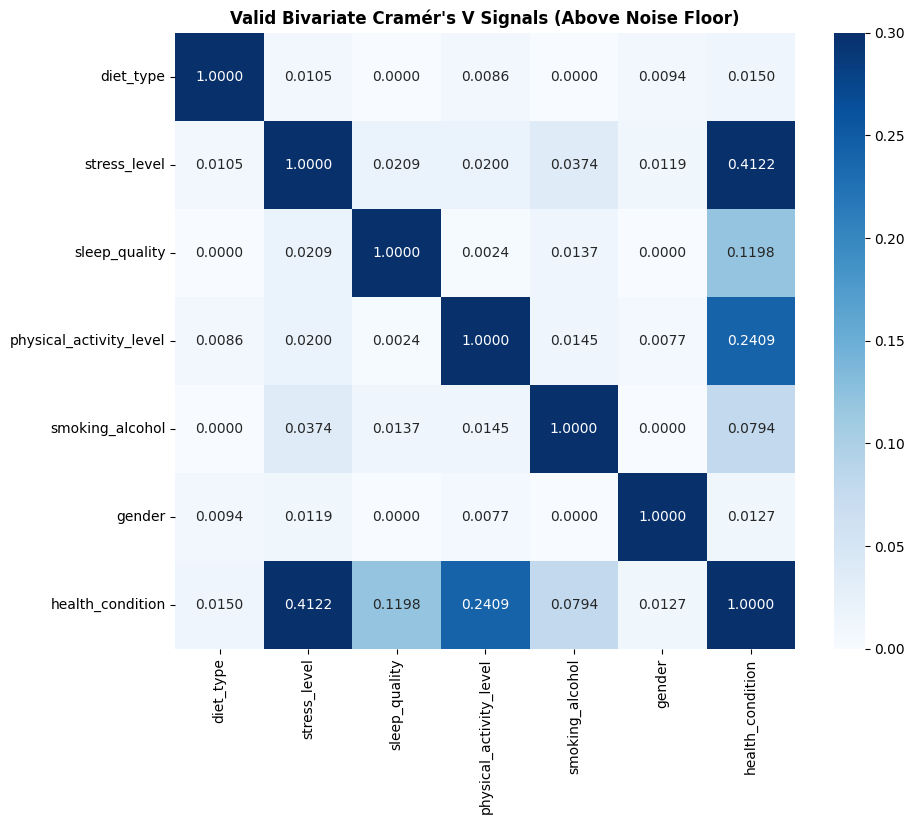

In [46]:
filtered_signal_matrix = actual_matrix.where(valid_mask,0.0)

plt.figure(figsize=(10, 8))
sns.heatmap(filtered_signal_matrix, annot=True, fmt=".4f", cmap="Blues", vmin=0, vmax=0.3)
plt.title("Valid Bivariate Cramér's V Signals (Above Noise Floor)", fontsize=12, fontweight="bold")
plt.show()

#### **Categorical Feature Correlation Summary:**

* `stress_level` and `physical_activity_level` show a moderate-to-strong correlation with the target variable (0.4122 and 0.2409 respectively).
* `sleep_quality` exhibits a weak correlation signal of ~0.120 against `health_condition`.
* Other features show very weak signals, but they are not all <0.01; `smoking_alcohol` is ~0.08, while `diet_type` and `gender` are ~0.015 and ~0.013.
* Bias-Corrected Cramer's V is identical to standard Cramer's V because the dataset has a massive sample size and exactly 3 categories across all qualitative features, which makes the bias correction penalty negligible.
* A noise threshold check reveals that 8 out of the 49 categorical feature pairs fail to meet the significance threshold.

## Adversarial Validation


In [47]:
train_df = df.drop(columns=['health_condition'])
train_df["is_test"] = 0
test["is_test"] = 1

stacked_df = pd.concat([train_df, test], axis=0, ignore_index=True)
stacked_df.head()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,is_test,id
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0,NaN
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0,NaN
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0,NaN
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0,NaN
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male,0,NaN


In [48]:
import lightgbm as lgb 
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold 

X = stacked_df.drop(columns=["id","is_test"])
y = stacked_df["is_test"]

cat_cols = X.select_dtypes(include=["category","object"]).columns
for col in cat_cols:
    X[col] = X[col].astype("category")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
feature_importance = np.zeros(X.shape[1])

for fold, (train_idx, val_idx) in enumerate(skf.split(X,y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        objective="binary",
        metric="auc",
        boosting_type="gbdt",
        learning_rate=0.05,
        num_leaves=31,
        n_estimators=300,
        random_state=42,
        verbose=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val,y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    oof_preds[val_idx] = model.predict_proba(X_val)[:,1]
    feature_importance += model.feature_importances_ / skf.n_splits

#  Overall Out-Of-Fold ROC-AUC Score
auc_score = roc_auc_score(y, oof_preds)
print(f"--- Adversarial Validation ROC-AUC: {auc_score:.4f} ---\n")

#  Top Drift-Inducing Features
importance_df = pd.DataFrame(
    {'feature': X.columns, 'importance': feature_importance}
).sort_values('importance', ascending=False)

print("Top Features Distinguishing Train vs Test:")
print(importance_df.head(5).to_string(index=False))

--- Adversarial Validation ROC-AUC: 0.6538 ---

Top Features Distinguishing Train vs Test:
                feature  importance
                    bmi       934.0
physical_activity_level       675.4
             step_count       529.6
           water_intake       465.0
    calorie_expenditure       455.6


#### Adversarial Validation Summary

* A Light Gradient Boosting Machine (LGBM) was trained to classify rows as training (0) or test (1) data (omitting the target) to evaluate dataset similarity, where an AUC near 0.5 indicates reliable cross-validation.
* The model achieved an AUC of `0.65`, indicating mild separation, and identified `bmi`, `physical_activity_level`, and `step_count` as the primary distinguishing features.
* The 0.65 AUC score is attributed to benign synthetic quantization artifacts rather than genuine distributional shifts, as feature importance is broadly distributed without visible per-feature gaps.
* Since no genuine per-feature drift was found, CV metrics are trustworthy and no features need dropping or reweighting.

In [49]:
stacked_df.groupby("is_test")["bmi"].apply(lambda s: s.isna().mean())

is_test
0    0.020139
1    0.020138
Name: bmi, dtype: float64

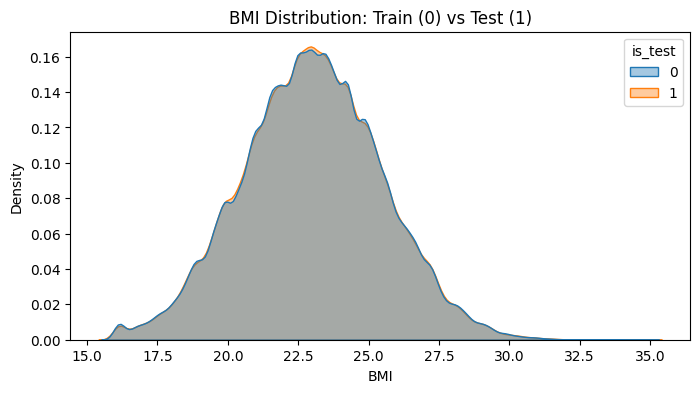

In [50]:
plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=stacked_df, 
    x='bmi', 
    hue='is_test', 
    common_norm=False, 
    fill=True, 
    alpha=0.4
)
plt.title("BMI Distribution: Train (0) vs Test (1)")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.show()


#### Feature Deep-Dive: Analyzing `bmi`

* `bmi` was explicitly checked because it ranked as the highest feature driving the mild separation in the adversarial validation model.
* Subsequent analysis revealed a consistent missing data rate of ~2% in both sets and nearly perfectly overlapping KDE distributions for non-missing values, confirming an absence of actual drift.

## Feature Interaction Check: `sleep_duration` vs `sleep_quality`

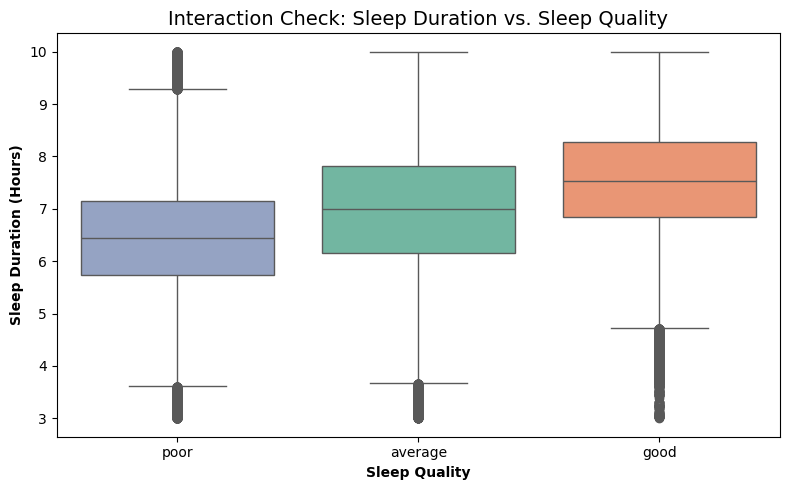

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, 
    x='sleep_quality', 
    y='sleep_duration', 
    palette='Set2',
    order=['poor', 'average', 'good'], # Orders the x-axis logically
    hue="sleep_quality",
    legend=False
)

plt.title("Interaction Check: Sleep Duration vs. Sleep Quality", fontsize=14)
plt.xlabel("Sleep Quality", fontweight='bold')
plt.ylabel("Sleep Duration (Hours)", fontweight='bold')
plt.tight_layout()
plt.show()

#### Summary

* A gentle, monotonic trend exists where median `sleep_duration` climbs $6.4 \rightarrow 7.0 \rightarrow 7.5$ hours across poor, average, and good `sleep_quality` levels.
* Despite this trend, there is massive overlap between categories, with every box spanning roughly $6$ to `$8$` hours, meaning a $7$-hour sleep could easily belong to any quality tier.
* Class separation is weak because the medians differ by only $\sim 1$ hour while the interquartile range (box width) spans $\sim 1.5$ hours.
* **Verdict:** Both features are independent and provide unique information, so both should be retained for modeling.
* The expected $\eta^2$ value is predicted to be small ($\sim 0.05 - 0.10$), nowhere near the $> 0.5$ threshold that would flag them as completely redundant.

## Multivariate Analysis: U-map 2D Projection

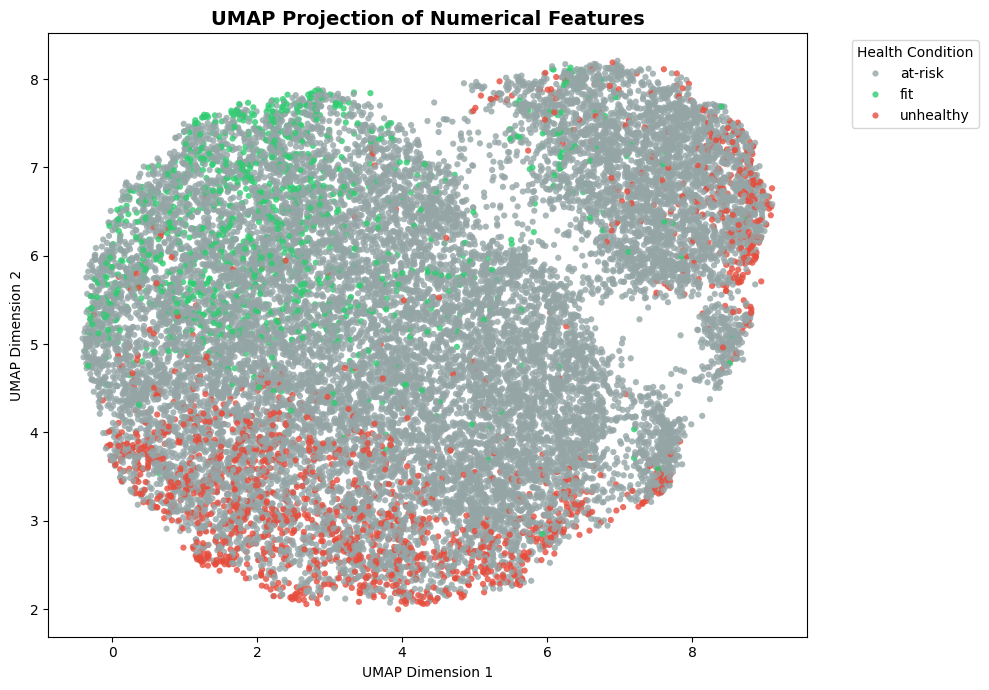

In [52]:
import umap
from sklearn.preprocessing import StandardScaler

sample_df = df[quantative + ['health_condition']].dropna().sample(n=20000, random_state=42)

X = sample_df[quantative]
y = sample_df['health_condition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit UMAP
reducer = umap.UMAP(n_neighbors=30, min_dist=0.05, n_components=2)
umap_results = reducer.fit_transform(X_scaled)

#  Plot the results with a semantic, high-contrast palette
custom_colors = {
    'fit': '#2ecc71',       # Vibrant Green
    'at-risk': '#95a5a6',   # Muted Grey
    'unhealthy': '#e74c3c'  # Strong Red
}

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=umap_results[:, 0], 
    y=umap_results[:, 1], 
    hue=y, 
    palette=custom_colors, 
    alpha=0.8,
    s=20,
    edgecolor='none'
)

plt.title("UMAP Projection of Numerical Features", fontsize=14, fontweight='bold')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Health Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()





### TODO : 

- Summary of what I have done and methods used
- Ask for upvote button on the bootom or middle
- Finding summary on top
- A final huge summary on the bottom
- All potential new Features ideas we got